# Running NRSS Simulations — S. Cheng et al.

This notebook walks through the code used to generate data used in **Figure 7** in the paper.
Section 3 (CyRSoXS simulation) requires a GPU; Sections 1 and 2 (morphology
generation) can run on a standard desktop or laptop.

**To reproduce all results, run the entire notebook top-to-bottom.**  
**Final version of Notebook was cleaned and partially annotated by Claude, and subsequently checked for accuracy**

## Contents

1. Nucleation & Growth morphology generation walkthrough
2. Cahn–Hilliard (spinodal decomposition) morphology generation
3. NRSS-simulated RSoXS on the two morphologies, simulated RSoXS integration
   and analysis.

## Configuration

Set the paths below to match your local directory structure before running.

In [14]:
import os

# Root directory containing input data (AFM file, optical constants, etc.)
DATA_DIR = os.path.abspath('../')
#DATA_DIR = os.path.abspath('/home/cbishop/TPD-TCTA/')

# Directory where simulation results and figures will be saved
RESULTS_DIR = os.path.abspath('../SimResults/')
#RESULTS_DIR = os.path.abspath('/home/cbishop/')
os.makedirs(RESULTS_DIR, exist_ok=True)

## Necessary imports

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
import sys
import cv2
import pySPM as spm
from matplotlib.colors import LogNorm

# Ensure the phase_separation package is importable
sys.path.append(os.path.abspath('..'))


from simulation import PhaseSimulation
from visualization import visualize_simulation, visualize_phase_evolution

## GPU-dependent imports

> **Skip this cell if you do not have a GPU.**

In [16]:
from NRSS.morphology import Morphology, Material, OpticalConstants
import NRSS.reader as read
import NRSS.visualizer as viz
from NRSS.writer import write_materials, write_hdf5, write_config, write_slurm

# 0.5. AFM height map

Here we import experimental AFM data. We filter the data to eliminate a few
spurious points and limit the AFM height map to the top 10 nm of our film model
(necessary to keep the model to a reasonable scale). The map is then resized to
match the pixel dimensions used in morphology generation.

Text(0, 0.5, 'Pixels')

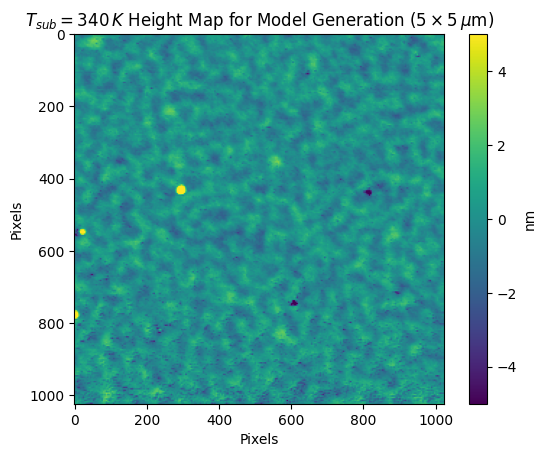

In [17]:
channel_name = 'Height Sensor'
#rawAFM = os.path.join(DATA_DIR, 'SI_scripts', 'Tsub_340K_5x5um.001')
rawAFM = os.path.join(DATA_DIR, 'SI_scripts', 'Tsub_340K_5x5um.001')
scan = spm.Bruker(rawAFM)
channel1 = scan.get_channel(channel_name)
channel_corr = channel1.correct_lines(inline=False)
channel = channel_corr.pixels
AFM_filter = channel

# Clip to ±5 nm to remove spurious outliers
AFM_filter[np.where(AFM_filter < -5)] = -5
AFM_filter[np.where(AFM_filter > 5)] = 5

# Resize to match morphology pixel dimensions (4× dilation)
AFM_filter = np.kron(AFM_filter, np.ones((4, 4)))

plt.imshow(AFM_filter)
plt.colorbar(label='nm')
plt.title(r'$T_{sub}=340\,K$ Height Map for Model Generation ($5\times5\,\mu$m)')
plt.xlabel('Pixels')
plt.ylabel('Pixels')

# 1. Generate Nucleation and Growth morphologies

This simulation generates a morphology with 27 layers, each 1024 × 1024 pixels,
with 5 equilibration steps per layer.

## a. Full 27-layer stack

We start at 2048 pixels per layer for sufficient detail, then downsample to
1024 × 1024 for computational efficiency. Volume fractions of TPD in each phase
(A, B, and mixed) are initialized here, along with arrays that will accumulate
the per-layer morphology.

In [43]:
dside = 2048       # initial layer size (pixels)
fA_TPD = 0.59      # volume fraction of TPD in phase A
fB_TPD = 0.48      # volume fraction of TPD in phase B

TPD27NG  = np.empty(shape=(0, 0))   # will accumulate per-layer TPD profiles
TCTA27NG = np.empty(shape=(0, 0))

mixed_pcts = []    # percentage of mixed phase remaining in each layer
Apcts = []         # percentage of nucleated phase that is phase A

Now we run the nucleation-and-growth simulation for each of the 27 layers. This may take several minutes.

In [44]:
m = 5              # equilibration steps per layer
np.random.seed(33) # ensures reproducible results

for i in range(27):
    dims = [dside, dside]
    grate = 4.0        # growth rate (empirically tuned to match physical system)
    npa = 0.000005     # nucleation probability, phase A
    npb = 0.000006     # nucleation probability, phase B
    sim = PhaseSimulation(
        dimensions=dims, growth_rate=grate,
        nucleation_prob_a=npa, nucleation_prob_b=npb
    )

    step = 0
    mixed_phase_exists = True
    stats_history = []

    while mixed_phase_exists and step < m:
        mixed_phase_exists = sim.step()
        stats = sim.get_phase_stats()
        stats_history.append(stats)
        step += 1

    pct_A = (stats['phase_a_percent'] /
             (stats['phase_a_percent'] + stats['phase_b_percent'])) * 100
    print(f"Layer {i+1:2d}: {m} steps → "
          f"{round(stats['mixed_phase_percent'], 0):.0f}% mixed, "
          f"{round(pct_A, 1):.1f}% transformed is phase A")
    mixed_pcts.append(round(stats['mixed_phase_percent'], 2))
    Apcts.append(round(pct_A, 2))

    # Downsample to 1024×1024 for computational efficiency
    half = cv2.resize(sim.grid, (1024, 1024))

    phaseA = half == 1
    phaseB = half == 2
    mixed  = half == 0

    Vfrac_TPD  = np.expand_dims(phaseA * fA_TPD + phaseB * fB_TPD + mixed * 0.5, axis=0)
    Vfrac_TCTA = np.expand_dims(phaseA * (1 - fA_TPD) + phaseB * (1 - fB_TPD) + mixed * 0.5, axis=0)

    if TPD27NG.shape == (0, 0):
        TPD27NG  = Vfrac_TPD
        TCTA27NG = Vfrac_TCTA
    else:
        TPD27NG  = np.concatenate((TPD27NG,  Vfrac_TPD),  axis=0)
        TCTA27NG = np.concatenate((TCTA27NG, Vfrac_TCTA), axis=0)

Layer  1: 5 steps → 97% mixed, 44.6% transformed is phase A
Layer  2: 5 steps → 98% mixed, 45.3% transformed is phase A
Layer  3: 5 steps → 97% mixed, 61.4% transformed is phase A
Layer  4: 5 steps → 97% mixed, 50.3% transformed is phase A
Layer  5: 5 steps → 97% mixed, 54.9% transformed is phase A
Layer  6: 5 steps → 97% mixed, 40.1% transformed is phase A
Layer  7: 5 steps → 97% mixed, 50.6% transformed is phase A
Layer  8: 5 steps → 97% mixed, 45.5% transformed is phase A
Layer  9: 5 steps → 97% mixed, 44.0% transformed is phase A
Layer 10: 5 steps → 97% mixed, 42.4% transformed is phase A
Layer 11: 5 steps → 98% mixed, 41.2% transformed is phase A
Layer 12: 5 steps → 97% mixed, 43.2% transformed is phase A
Layer 13: 5 steps → 97% mixed, 48.1% transformed is phase A
Layer 14: 5 steps → 98% mixed, 41.6% transformed is phase A
Layer 15: 5 steps → 97% mixed, 50.0% transformed is phase A
Layer 16: 5 steps → 97% mixed, 47.2% transformed is phase A
Layer 17: 5 steps → 97% mixed, 46.3% tra

### Apply AFM surface topography

The AFM height map is used to carve out vacuum regions in the top 2 layers of the model.

In [50]:
import copy
TPD27NG = copy.deepcopy(TPD27)
TCTA27NG = copy.deepcopy(TCTA27)

In [51]:
vac_filt = np.zeros((27, 1024, 1024))

for i in range(AFM_filter.shape[0]):
    for j in range(AFM_filter.shape[1]):
        h = AFM_filter[i, j]
        if h <= 0:
            vac_filt[-1, i, j] = 1.
            vac_filt[-2, i, j] = round(abs(h) / 5., 3)
        else:
            vac_filt[-1, i, j] = round(1. - h / 5., 3)
            vac_filt[-2, i, j] = 0.

inverse_vac = 1. - vac_filt
TPD27_corrNG  = TPD27NG  * inverse_vac
TCTA27_corrNG = TCTA27NG * inverse_vac

### Figure S18a — top 4 layers of the NG morphology

Plots the top 20 nm of the model (top 4 layers × 5 nm each) over a 2.5 × 2.5 µm field of view.

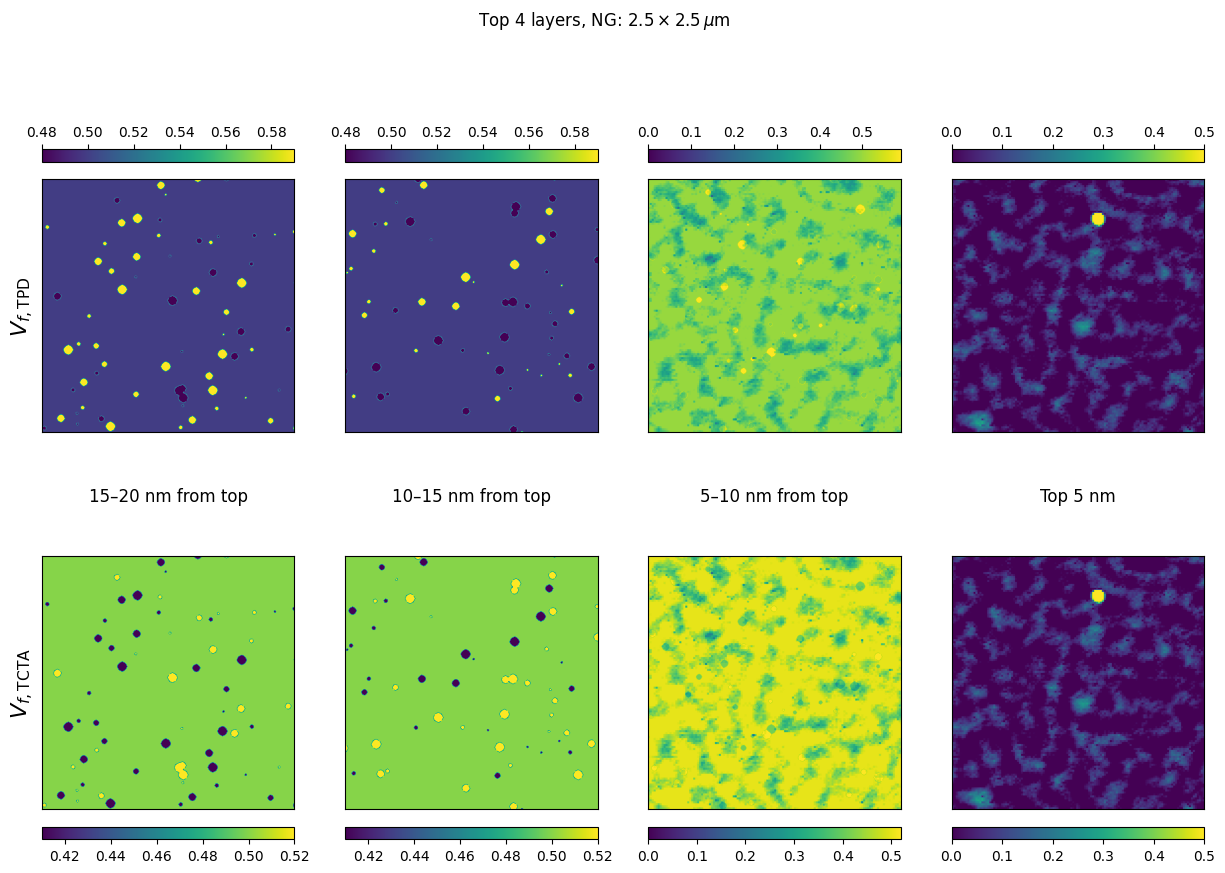

In [21]:
plt.close()
fig, ax = plt.subplots(2, 4, figsize=(15, 10))

for col, idx in enumerate([-4, -3, -2, -1]):
    cb = ax[0, col].imshow(TPD27_corrNG[idx])
    plt.colorbar(cb, ax=ax[0, col], location='top', pad=0.05)
    cb = ax[1, col].imshow(TCTA27_corrNG[idx])
    plt.colorbar(cb, ax=ax[1, col], location='bottom', pad=0.05)

for row in ax:
    for a in row:
        a.set_xticks([]); a.set_yticks([])
        a.set_xlim(0, 512); a.set_ylim(0, 512)

depth_labels = ['15–20 nm from top', '10–15 nm from top', '5–10 nm from top', 'Top 5 nm']
for col, lbl in enumerate(depth_labels):
    ax[1, col].set_title(lbl, pad=40)

ax[0, 0].set_ylabel(r'$V_{f,\mathrm{TPD}}$',  fontsize=16)
ax[1, 0].set_ylabel(r'$V_{f,\mathrm{TCTA}}$', fontsize=16)
plt.suptitle(r'Top 4 layers, NG: $2.5\times2.5\,\mu$m')

plt.savefig(os.path.join(RESULTS_DIR, 'S18_NGtoplayers_2p5.png'), dpi=200, bbox_inches='tight')

### Demo: single-layer NG simulation for 1–15 steps

Shows how the morphology evolves with increasing equilibration time for a single layer.

In [22]:
msteps = np.arange(1, 16, dtype=int)
holder = np.zeros((15, 1024, 1024))
np.random.seed(33)

for m in msteps:
    dims = [dside, dside]
    sim = PhaseSimulation(
        dimensions=dims, growth_rate=4.0,
        nucleation_prob_a=0.000005, nucleation_prob_b=0.000006
    )
    step = 0
    mixed_phase_exists = True
    while mixed_phase_exists and step < m:
        mixed_phase_exists = sim.step()
        stats = sim.get_phase_stats()
        step += 1

    pct_A = (stats['phase_a_percent'] /
             (stats['phase_a_percent'] + stats['phase_b_percent'])) * 100
    print(f"{m:2d} steps → {round(stats['mixed_phase_percent'], 0):.0f}% mixed, "
          f"{round(pct_A, 1):.1f}% transformed is phase A")

    half = cv2.resize(sim.grid, (1024, 1024))
    phaseA = half == 1; phaseB = half == 2; mixed = half == 0
    Vfrac_TPD = phaseA * fA_TPD + phaseB * fB_TPD + mixed * 0.5
    holder[m - 1] = Vfrac_TPD

 1 steps → 100% mixed, 47.0% transformed is phase A
 2 steps → 100% mixed, 37.3% transformed is phase A
 3 steps → 99% mixed, 41.0% transformed is phase A
 4 steps → 99% mixed, 47.3% transformed is phase A
 5 steps → 97% mixed, 44.4% transformed is phase A
 6 steps → 95% mixed, 46.7% transformed is phase A
 7 steps → 94% mixed, 44.1% transformed is phase A
 8 steps → 90% mixed, 41.0% transformed is phase A
 9 steps → 86% mixed, 53.6% transformed is phase A
10 steps → 83% mixed, 45.4% transformed is phase A
11 steps → 76% mixed, 47.5% transformed is phase A
12 steps → 73% mixed, 48.7% transformed is phase A
13 steps → 68% mixed, 46.0% transformed is phase A
14 steps → 61% mixed, 46.0% transformed is phase A
15 steps → 55% mixed, 43.7% transformed is phase A


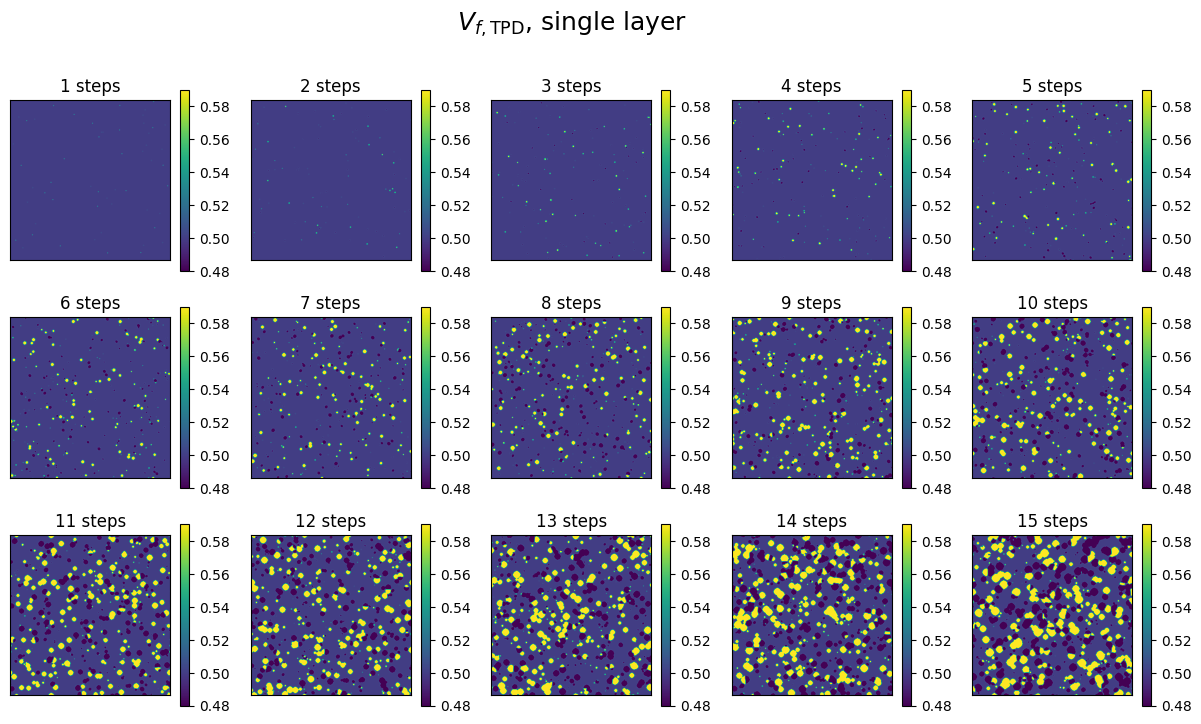

In [23]:
fig, axs = plt.subplots(3, 5, figsize=(15, 8))
ax_counter = axs.reshape(-1)
for m in msteps:
    cb = ax_counter[m - 1].imshow(holder[m - 1])
    plt.colorbar(cb, ax=ax_counter[m - 1])
    ax_counter[m - 1].set_title(f'{m} steps')
for a in ax_counter:
    a.set_xticks([]); a.set_yticks([])

plt.suptitle(r'$V_{f,\mathrm{TPD}}$, single layer', fontsize=18)
plt.savefig(os.path.join(RESULTS_DIR, 'S19_NG_msteps.png'), dpi=200, bbox_inches='tight')

# 2. Generate spinodal (Cahn–Hilliard) morphologies

In [24]:
sys.path.append(os.path.join(DATA_DIR, 'Scripts'))
import Cahn as ch

In [25]:
%%capture
np.random.seed(33)
dim = 1024       # Cahn–Hilliard does not require as high an initial resolution
fA_TPD = 0.59
fB_TPD = 0.48
cTPD = 0.53      # mean composition

TPD27  = np.empty(shape=(0, 0))
TCTA27 = np.empty(shape=(0, 0))

for i in range(27):
    ctry = ch.gen_spec_CH(c0=cTPD, W=2.0, M=1.0, Npix=dim, Nsteps=100, rngseed=i)
    final_morph = ctry[-1]

    Vfrac_TPD  = np.ones((dim, dim)) * final_morph
    Vfrac_TCTA = np.ones((dim, dim)) - Vfrac_TPD

    Vfrac_TPD  = np.expand_dims(Vfrac_TPD,  axis=0)
    Vfrac_TCTA = np.expand_dims(Vfrac_TCTA, axis=0)

    if TPD27.shape == (0, 0):
        TPD27  = Vfrac_TPD
        TCTA27 = Vfrac_TCTA
    else:
        TPD27  = np.concatenate((TPD27,  Vfrac_TPD),  axis=0)
        TCTA27 = np.concatenate((TCTA27, Vfrac_TCTA), axis=0)

# Apply AFM surface topography (same procedure as NG above)
vac_filt = np.zeros((27, 1024, 1024))
for i in range(AFM_filter.shape[0]):
    for j in range(AFM_filter.shape[1]):
        h = AFM_filter[i, j]
        if h <= 0:
            vac_filt[-1, i, j] = 1.
            vac_filt[-2, i, j] = round(abs(h) / 5., 3)
        else:
            vac_filt[-1, i, j] = round(1. - h / 5., 3)
            vac_filt[-2, i, j] = 0.

inverse_vac = 1. - vac_filt
TPD27_corr  = TPD27  * inverse_vac
TCTA27_corr = TCTA27 * inverse_vac
dim = 1024

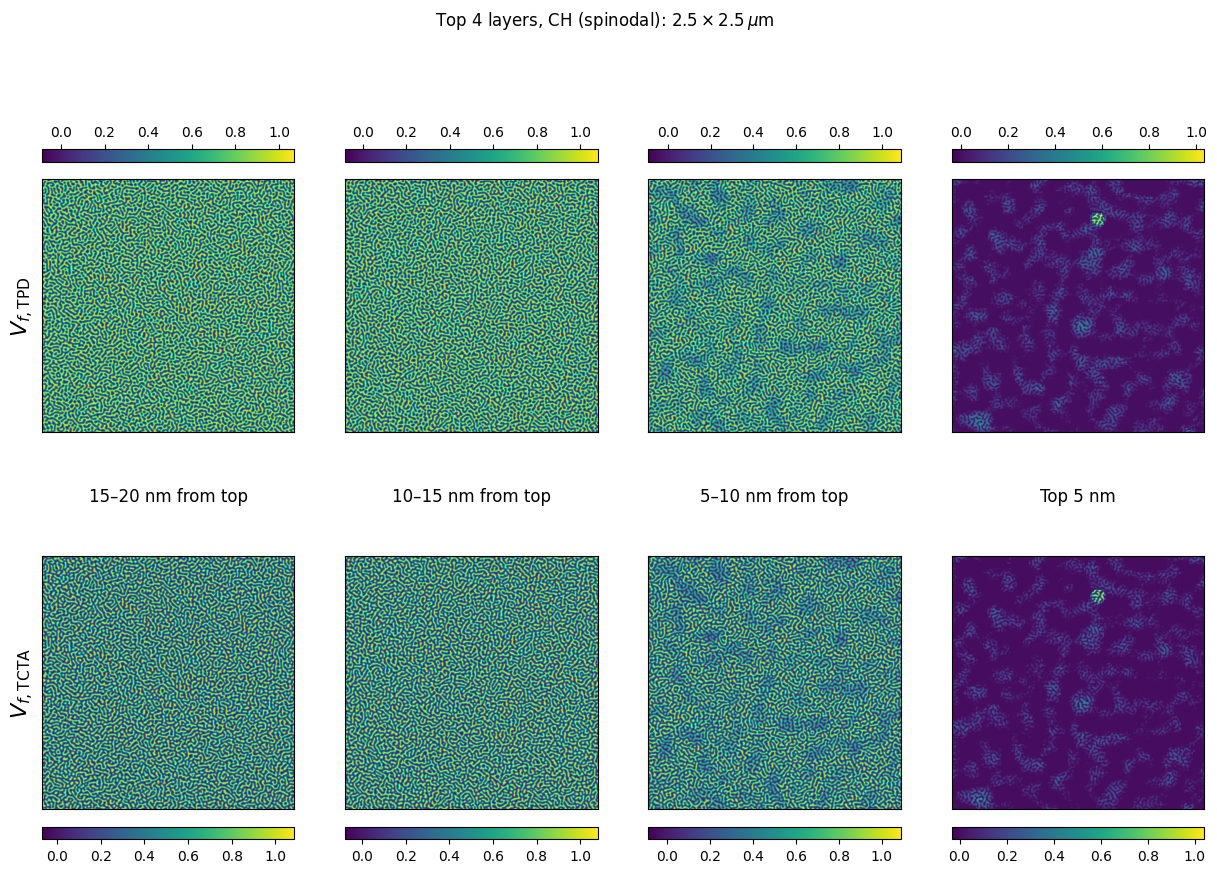

In [26]:
plt.close()
fig, ax = plt.subplots(2, 4, figsize=(15, 10))

for col, idx in enumerate([-4, -3, -2, -1]):
    cb = ax[0, col].imshow(TPD27_corr[idx])
    plt.colorbar(cb, ax=ax[0, col], location='top', pad=0.05)
    cb = ax[1, col].imshow(TCTA27_corr[idx])
    plt.colorbar(cb, ax=ax[1, col], location='bottom', pad=0.05)

for row in ax:
    for a in row:
        a.set_xticks([]); a.set_yticks([])
        a.set_xlim(0, 512); a.set_ylim(0, 512)

depth_labels = ['15–20 nm from top', '10–15 nm from top', '5–10 nm from top', 'Top 5 nm']
for col, lbl in enumerate(depth_labels):
    ax[1, col].set_title(lbl, pad=40)

ax[0, 0].set_ylabel(r'$V_{f,\mathrm{TPD}}$',  fontsize=16)
ax[1, 0].set_ylabel(r'$V_{f,\mathrm{TCTA}}$', fontsize=16)
plt.suptitle(r'Top 4 layers, CH (spinodal): $2.5\times2.5\,\mu$m')

plt.savefig(os.path.join(RESULTS_DIR, 'S18_CHtoplayers_2p5.png'), dpi=200, bbox_inches='tight')

# 3. NRSS simulation, integration, and analysis

In this section we set up the simulation energies and optical constants, run the
CyRSoXS GPU simulation, and integrate the 2-D scattering patterns.

> **This section requires a GPU.**

## 3a. Define simulation energies

In [27]:
# Full energy array used in the paper (uncomment to reproduce all energies):
# lowres  = [250.0, 260.0, 270.0, 272.0, 274.0, 276.0, 278.0, 280.0,
#            280.5, 281.0, 281.5, 282.0, 282.5]
# midres  = np.linspace(283, 292, 46)
# high    = np.linspace(292.5, 299.5, 15)
# highhigh = np.linspace(300., 340., 9)
# totalE  = np.concatenate((lowres, midres, high, highhigh))

# Reduced set for quick testing:
totalE = [270.0, 287.4, 350.0]

energies = totalE
print(f'Simulating {len(energies)} energies: {energies}')

Simulating 3 energies: [270.0, 287.4, 350.0]


## 3b. Write material files

This writes the energy-resolved optical-constants files into the current directory. Run this before building the morphology objects.

In [28]:
OCs_folder = DATA_DIR  # folder containing TPD_OCs.txt and TCTA_OCs.txt
material_dict = {
    'Material1': os.path.join(OCs_folder, 'TPD_OCs.txt'),
    'Material2': os.path.join(OCs_folder, 'TCTA_OCs.txt'),
    'Material3': 'vacuum',
}
energy_dict = {'Energy': 4, 'DeltaPerp': 3, 'BetaPerp': 1, 'DeltaPara': 2, 'BetaPara': 0}

write_materials(energies, material_dict, energy_dict, 3)

## 3c. NG morphology — build NRSS Morphology object

In [62]:
# Re-run Section 1 first (or ensure TPD27_corrNG and TCTA27_corrNG are in memory).
matfile_folder = os.getcwd()  # write_materials placed the files here
imgsize_nm = 5000.
dim = 1024
px_nm = float(imgsize_nm / dim)
zeros_mat = np.zeros_like(vac_filt, dtype=float)

mat1_consts = OpticalConstants.load_matfile(
    os.path.join(matfile_folder, 'Material1.txt'), name='Material 1')
mat1 = Material(materialID=1, Vfrac=TPD27_corrNG, S=zeros_mat,
                psi=zeros_mat, theta=zeros_mat, energies=energies,
                opt_constants=mat1_consts.opt_constants, name='Material 1')

mat2_consts = OpticalConstants.load_matfile(
    os.path.join(matfile_folder, 'Material2.txt'), name='Material 2')
mat2 = Material(materialID=2, Vfrac=TCTA27_corrNG, S=zeros_mat,
                psi=zeros_mat, theta=zeros_mat, energies=energies,
                opt_constants=mat2_consts.opt_constants, name='Material 2')

mat3 = Material(materialID=3, Vfrac=vac_filt, S=zeros_mat,
                psi=zeros_mat, theta=zeros_mat, energies=energies, name='vacuum')

morph = Morphology(3, materials={1: mat1, 2: mat2, 3: mat3},
                   PhysSize=px_nm, create_cy_object=True)
morph.check_materials(quiet=True)
morph.EAngleRotation = [0.0, 1.0, 360.0]
morph.WindowingType = 1

## 3d. Run CyRSoXS

> **Requires a GPU.** Run time scales with the number of energies.

In [63]:
scattering = morph.run()


 [STAT] Executing: 

Number of CUDA devices:1
[INFO] [GPU = NVIDIA RTX A6000] : 270eV -> 350eV
 [STAT] Energy = 270 starting 
 [STAT] Energy = 287.4 starting 
 [STAT] Energy = 350 starting 


## 3e. Integrate with PyHyperScattering  
Note that the below import often throws error messages; usually it should be fine. Ideally you should run in an environment that has a version of pyFAI before 2024.01, since the azimuthal integrator method was changed but the error has not been fixed in PyHyperScattering.

In [66]:
! pip install pyFAI==2023.09

  Obtaining dependency information for pyFAI==2023.09 from https://files.pythonhosted.org/packages/8d/8f/9fc0628da207cf9174f69b0ada39f0b2b89baa3de31185c0e4c98446138a/pyfai-2023.9.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 57.8 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: pyFAI
    Found existing installation: pyFAI 2024.5.0
    Uninstalling pyFAI-2024.5.0:
      Successfully uninstalled pyFAI-2024.5.0


In [68]:
from PyHyperScattering.integrate import WPIntegrator
integrator = WPIntegrator()
remeshed = integrator.integrateImageStack(scattering)

  0%|          | 0/3 [00:00<?, ?it/s]

/home/cbishop/anaconda3/envs/spm_soft/lib/python3.11/site-packages/xarray/core/concat.py:500: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


## 3f. Inspect and plot results

The integrator returns an `xarray.DataArray` with dimensions `(energy, chi, q)`.


### Xarray structure

In [69]:
remeshed

<xarray.DataArray (energy: 3, chi: 360, q: 725)>
array([[[ 376551.78 ,  286290.56 ,   19576.535, ...,       0.   ,
               0.   ,       0.   ],
        [ 376551.78 ,  284013.75 ,   19127.17 , ...,       0.   ,
               0.   ,       0.   ],
        [ 376551.78 ,  281765.75 ,   18833.023, ...,       0.   ,
               0.   ,       0.   ],
        ...,
        [ 376551.78 ,  279547.97 ,   18686.797, ...,       0.   ,
               0.   ,       0.   ],
        [ 376551.78 ,  281765.75 ,   18833.025, ...,       0.   ,
               0.   ,       0.   ],
        [ 376551.78 ,  284013.75 ,   19127.17 , ...,       0.   ,
               0.   ,       0.   ]],

       [[1060863.8  ,  806563.   ,   55152.734, ...,       0.   ,
               0.   ,       0.   ],
        [1060863.8  ,  800148.5  ,   53886.742, ...,       0.   ,
               0.   ,       0.   ],
        [1060863.8  ,  793815.25 ,   53058.055, ...,       0.   ,
               0.   ,       0.   ],
...
        [1060863.8  ,  787567.1  ,   52646.086, ...,       0.   ,
               0.   ,       0.   ],
        [1060863.8  ,  793815.3  ,   53058.055, ...,       0.   ,
               0.   ,       0.   ],
        [1060863.8  ,  800148.56 ,   53886.742, ...,       0.   ,
               0.   ,       0.   ]],

       [[3506802.8  , 2666199.2  ,  182314.97 , ...,       0.   ,
               0.   ,       0.   ],
        [3506802.8  , 2644995.2  ,  178130.05 , ...,       0.   ,
               0.   ,       0.   ],
        [3506802.8  , 2624060.2  ,  175390.7  , ...,       0.   ,
               0.   ,       0.   ],
        ...,
        [3506802.8  , 2603406.   ,  174028.89 , ...,       0.   ,
               0.   ,       0.   ],
        [3506802.8  , 2624060.2  ,  175390.7  , ...,       0.   ,
               0.   ,       0.   ],
        [3506802.8  , 2644995.5  ,  178130.06 , ...,       0.   ,
               0.   ,       0.   ]]], dtype=float32)
Coordinates:
  * q        (q) float64 0.0 0.001257 0.002514 0.00377 ... 0.9074 0.9086 0.9099
  * chi      (chi) float64 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * energy   (energy) float64 270.0 287.4 350.0

### $\chi$–$q$ maps

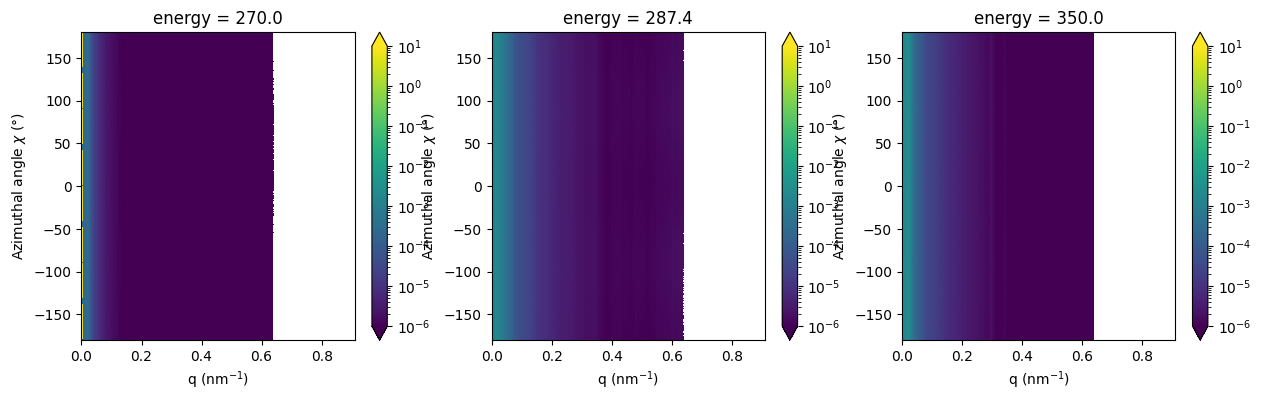

In [70]:
fig, ax = plt.subplots(1, len(energies), figsize=(5 * len(energies), 4))
if len(energies) == 1:
    ax = [ax]
for a, e in zip(ax, energies):
    remeshed.sel(energy=e).plot(norm=LogNorm(1e-6, 10), ax=a)
    a.set_xlabel(r'q (nm$^{-1}$)')
    a.set_ylabel(r'Azimuthal angle $\chi$ (°)')

### Integrated scattering profiles

Text(0.5, 1.0, 'Integrated over $\\chi \\in (-45°, 45°)$')

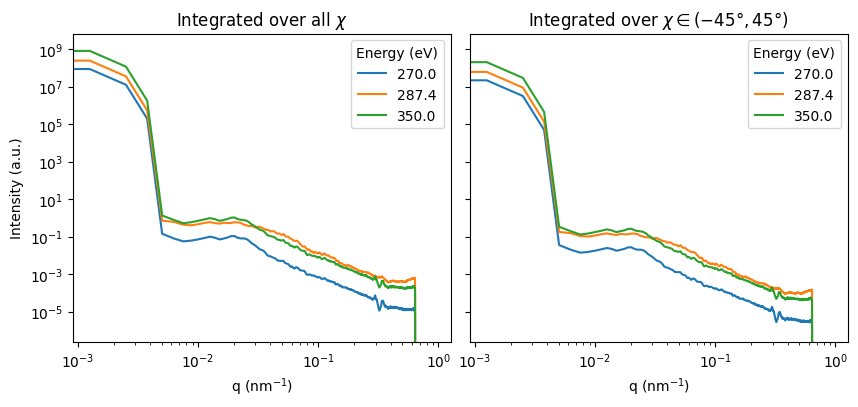

In [71]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
plt.subplots_adjust(wspace=0.05)

for e in np.asarray(remeshed.energy):
    remeshed.sel(energy=e).sum('chi').plot(ax=ax[0], label=e)
    remeshed.sel(energy=e).sel(chi=slice(-45, 45)).sum('chi').plot(ax=ax[1], label=e)

for a in ax:
    a.loglog()
    a.legend(title='Energy (eV)')
    a.set_xlabel(r'q (nm$^{-1}$)')

ax[0].set_ylabel('Intensity (a.u.)')
ax[0].set_title(r'Integrated over all $\chi$')
ax[1].set_title(r'Integrated over $\chi \in (-45°, 45°)$')

For further guidance on extracting quantitative information from NRSS data,
see the NRSS tutorial and Dudenas et al., *J. Chem. Phys.* **163**, 061501 (2025).
<https://doi.org/10.1063/5.0267709>

## 3g. CH morphology — build NRSS Morphology object and run

Re-generates the Cahn–Hilliard morphology and runs the CyRSoXS simulation on it.

In [72]:
sys.path.append(os.path.join(DATA_DIR, 'Scripts'))
import rsoxsCahn as ch

In [73]:
qch1 = (0.009, 0.015)   # low-q integration window (nm⁻¹)
qch2 = (0.05,  0.06)    # mid-q integration window (nm⁻¹)
dim = 1024
cTPD = 0.53

TPD27  = np.empty(shape=(0, 0))
TCTA27 = np.empty(shape=(0, 0))

for i in range(27):
    ctry = ch.gen_spec_CH(c0=cTPD, W=0.3, M=1.0, Npix=dim, Nsteps=1000, rngseed=i)
    final_morph = ctry[-1]

    Vfrac_TPD  = np.ones((dim, dim)) * final_morph
    Vfrac_TCTA = np.ones((dim, dim)) - Vfrac_TPD

    Vfrac_TPD  = np.expand_dims(Vfrac_TPD,  axis=0)
    Vfrac_TCTA = np.expand_dims(Vfrac_TCTA, axis=0)

    if TPD27.shape == (0, 0):
        TPD27  = Vfrac_TPD
        TCTA27 = Vfrac_TCTA
    else:
        TPD27  = np.concatenate((TPD27,  Vfrac_TPD),  axis=0)
        TCTA27 = np.concatenate((TCTA27, Vfrac_TCTA), axis=0)

# Apply AFM surface topography
vac_filt = np.zeros((27, 1024, 1024))
for i in range(AFM_filter.shape[0]):
    for j in range(AFM_filter.shape[1]):
        h = AFM_filter[i, j]
        if h <= 0:
            vac_filt[-1, i, j] = 1.
            vac_filt[-2, i, j] = round(abs(h) / 5., 3)
        else:
            vac_filt[-1, i, j] = round(1. - h / 5., 3)
            vac_filt[-2, i, j] = 0.

inverse_vac = 1. - vac_filt
TPD27_corr  = TPD27  * inverse_vac
TCTA27_corr = TCTA27 * inverse_vac

imgsize_nm = 5000.
px_nm = float(imgsize_nm / dim)
zeros_mat = np.zeros_like(vac_filt, dtype=float)

returning whole time series
returning whole time series
returning whole time series
returning whole time series
returning whole time series
returning whole time series
returning whole time series
returning whole time series
returning whole time series
returning whole time series
returning whole time series
returning whole time series
returning whole time series
returning whole time series
returning whole time series
returning whole time series
returning whole time series
returning whole time series
returning whole time series
returning whole time series
returning whole time series
returning whole time series
returning whole time series
returning whole time series
returning whole time series
returning whole time series
returning whole time series


In [74]:
mat1_consts = OpticalConstants.load_matfile(
    os.path.join(matfile_folder, 'Material1.txt'), name='Material 1')
mat1 = Material(materialID=1, Vfrac=TPD27_corr, S=zeros_mat,
                psi=zeros_mat, theta=zeros_mat, energies=energies,
                opt_constants=mat1_consts.opt_constants, name='Material 1')

mat2_consts = OpticalConstants.load_matfile(
    os.path.join(matfile_folder, 'Material2.txt'), name='Material 2')
mat2 = Material(materialID=2, Vfrac=TCTA27_corr, S=zeros_mat,
                psi=zeros_mat, theta=zeros_mat, energies=energies,
                opt_constants=mat2_consts.opt_constants, name='Material 2')

mat3 = Material(materialID=3, Vfrac=vac_filt, S=zeros_mat,
                psi=zeros_mat, theta=zeros_mat, energies=energies, name='vacuum')

morph = Morphology(3, materials={1: mat1, 2: mat2, 3: mat3},
                   PhysSize=px_nm, create_cy_object=True)
morph.check_materials(quiet=True)
morph.EAngleRotation = [0.0, 1.0, 360.0]
morph.WindowingType = 1

Dataset dimensions (Z, Y, X): 27 x 1024 x 1024
Number of Materials: 3

Material 1 Vfrac. Min: 0.0 Max: 0.9866971373558044
Material 1 S. Min: 0.0 Max: 0.0
Material 1 theta. Min: 0.0 Max: 0.0
Material 1 psi. Min: 0.0 Max: 0.0


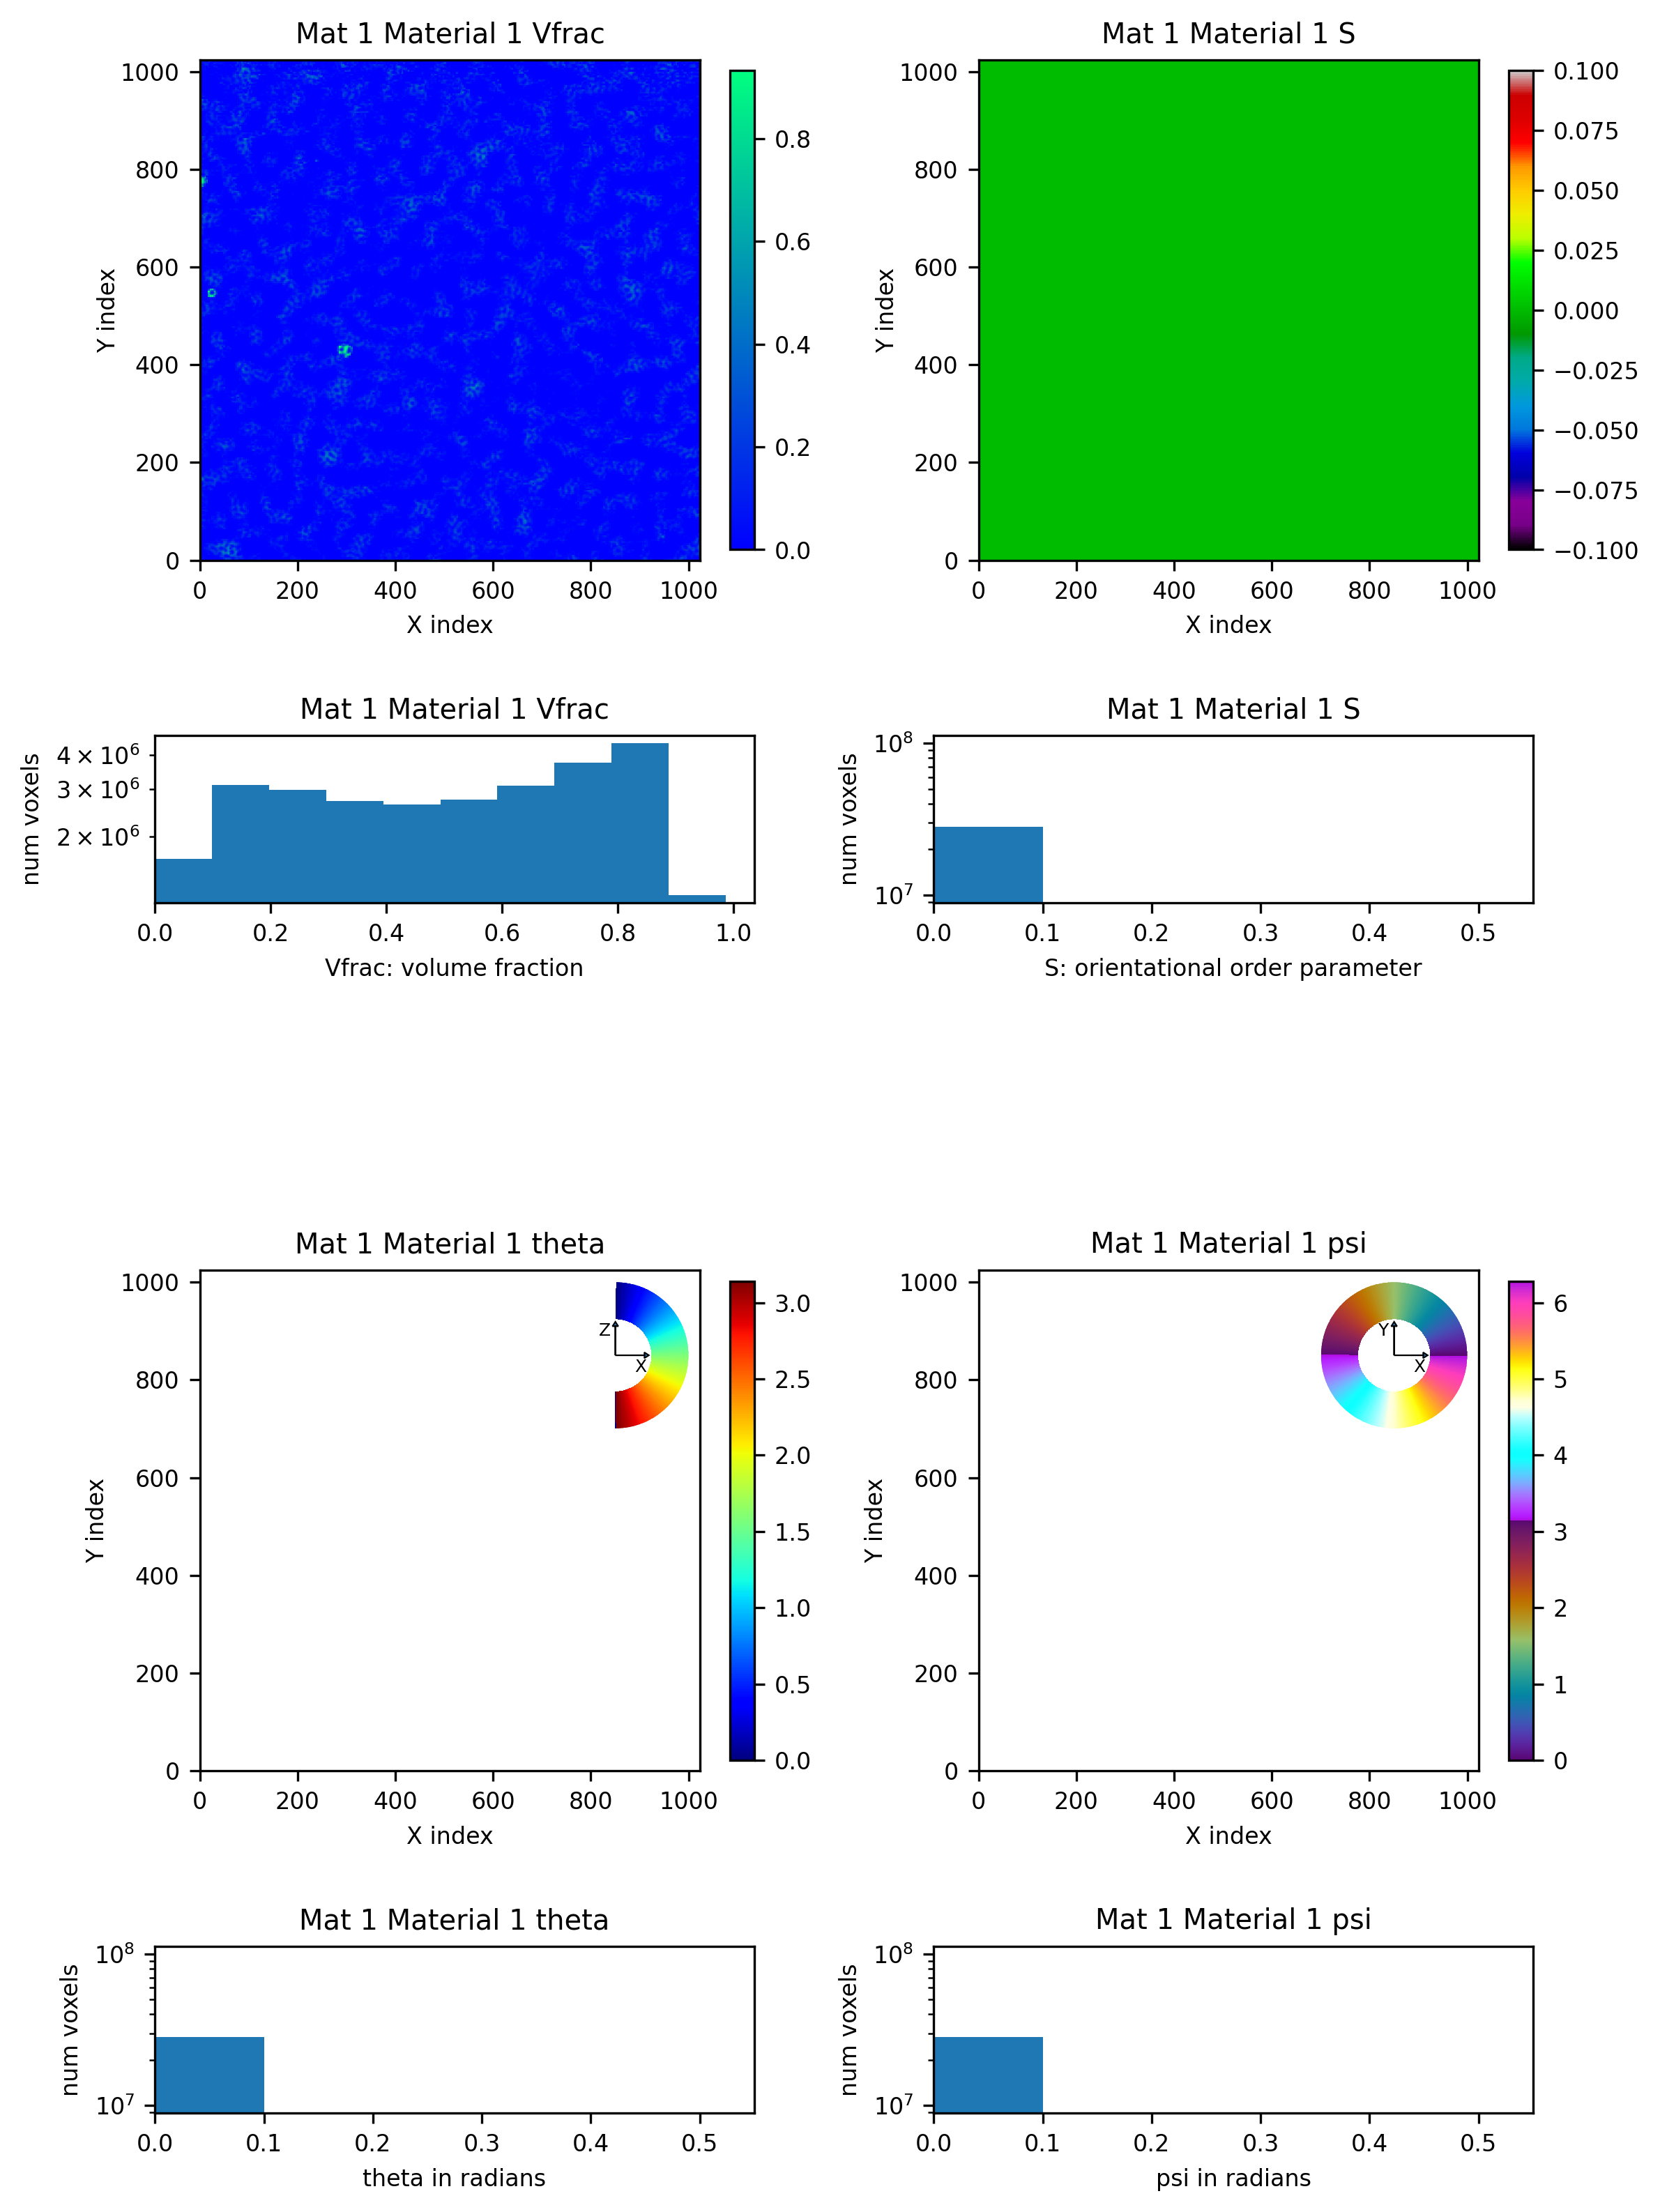

Material 2 Vfrac. Min: 0.0 Max: 0.9905219674110413
Material 2 S. Min: 0.0 Max: 0.0
Material 2 theta. Min: 0.0 Max: 0.0
Material 2 psi. Min: 0.0 Max: 0.0


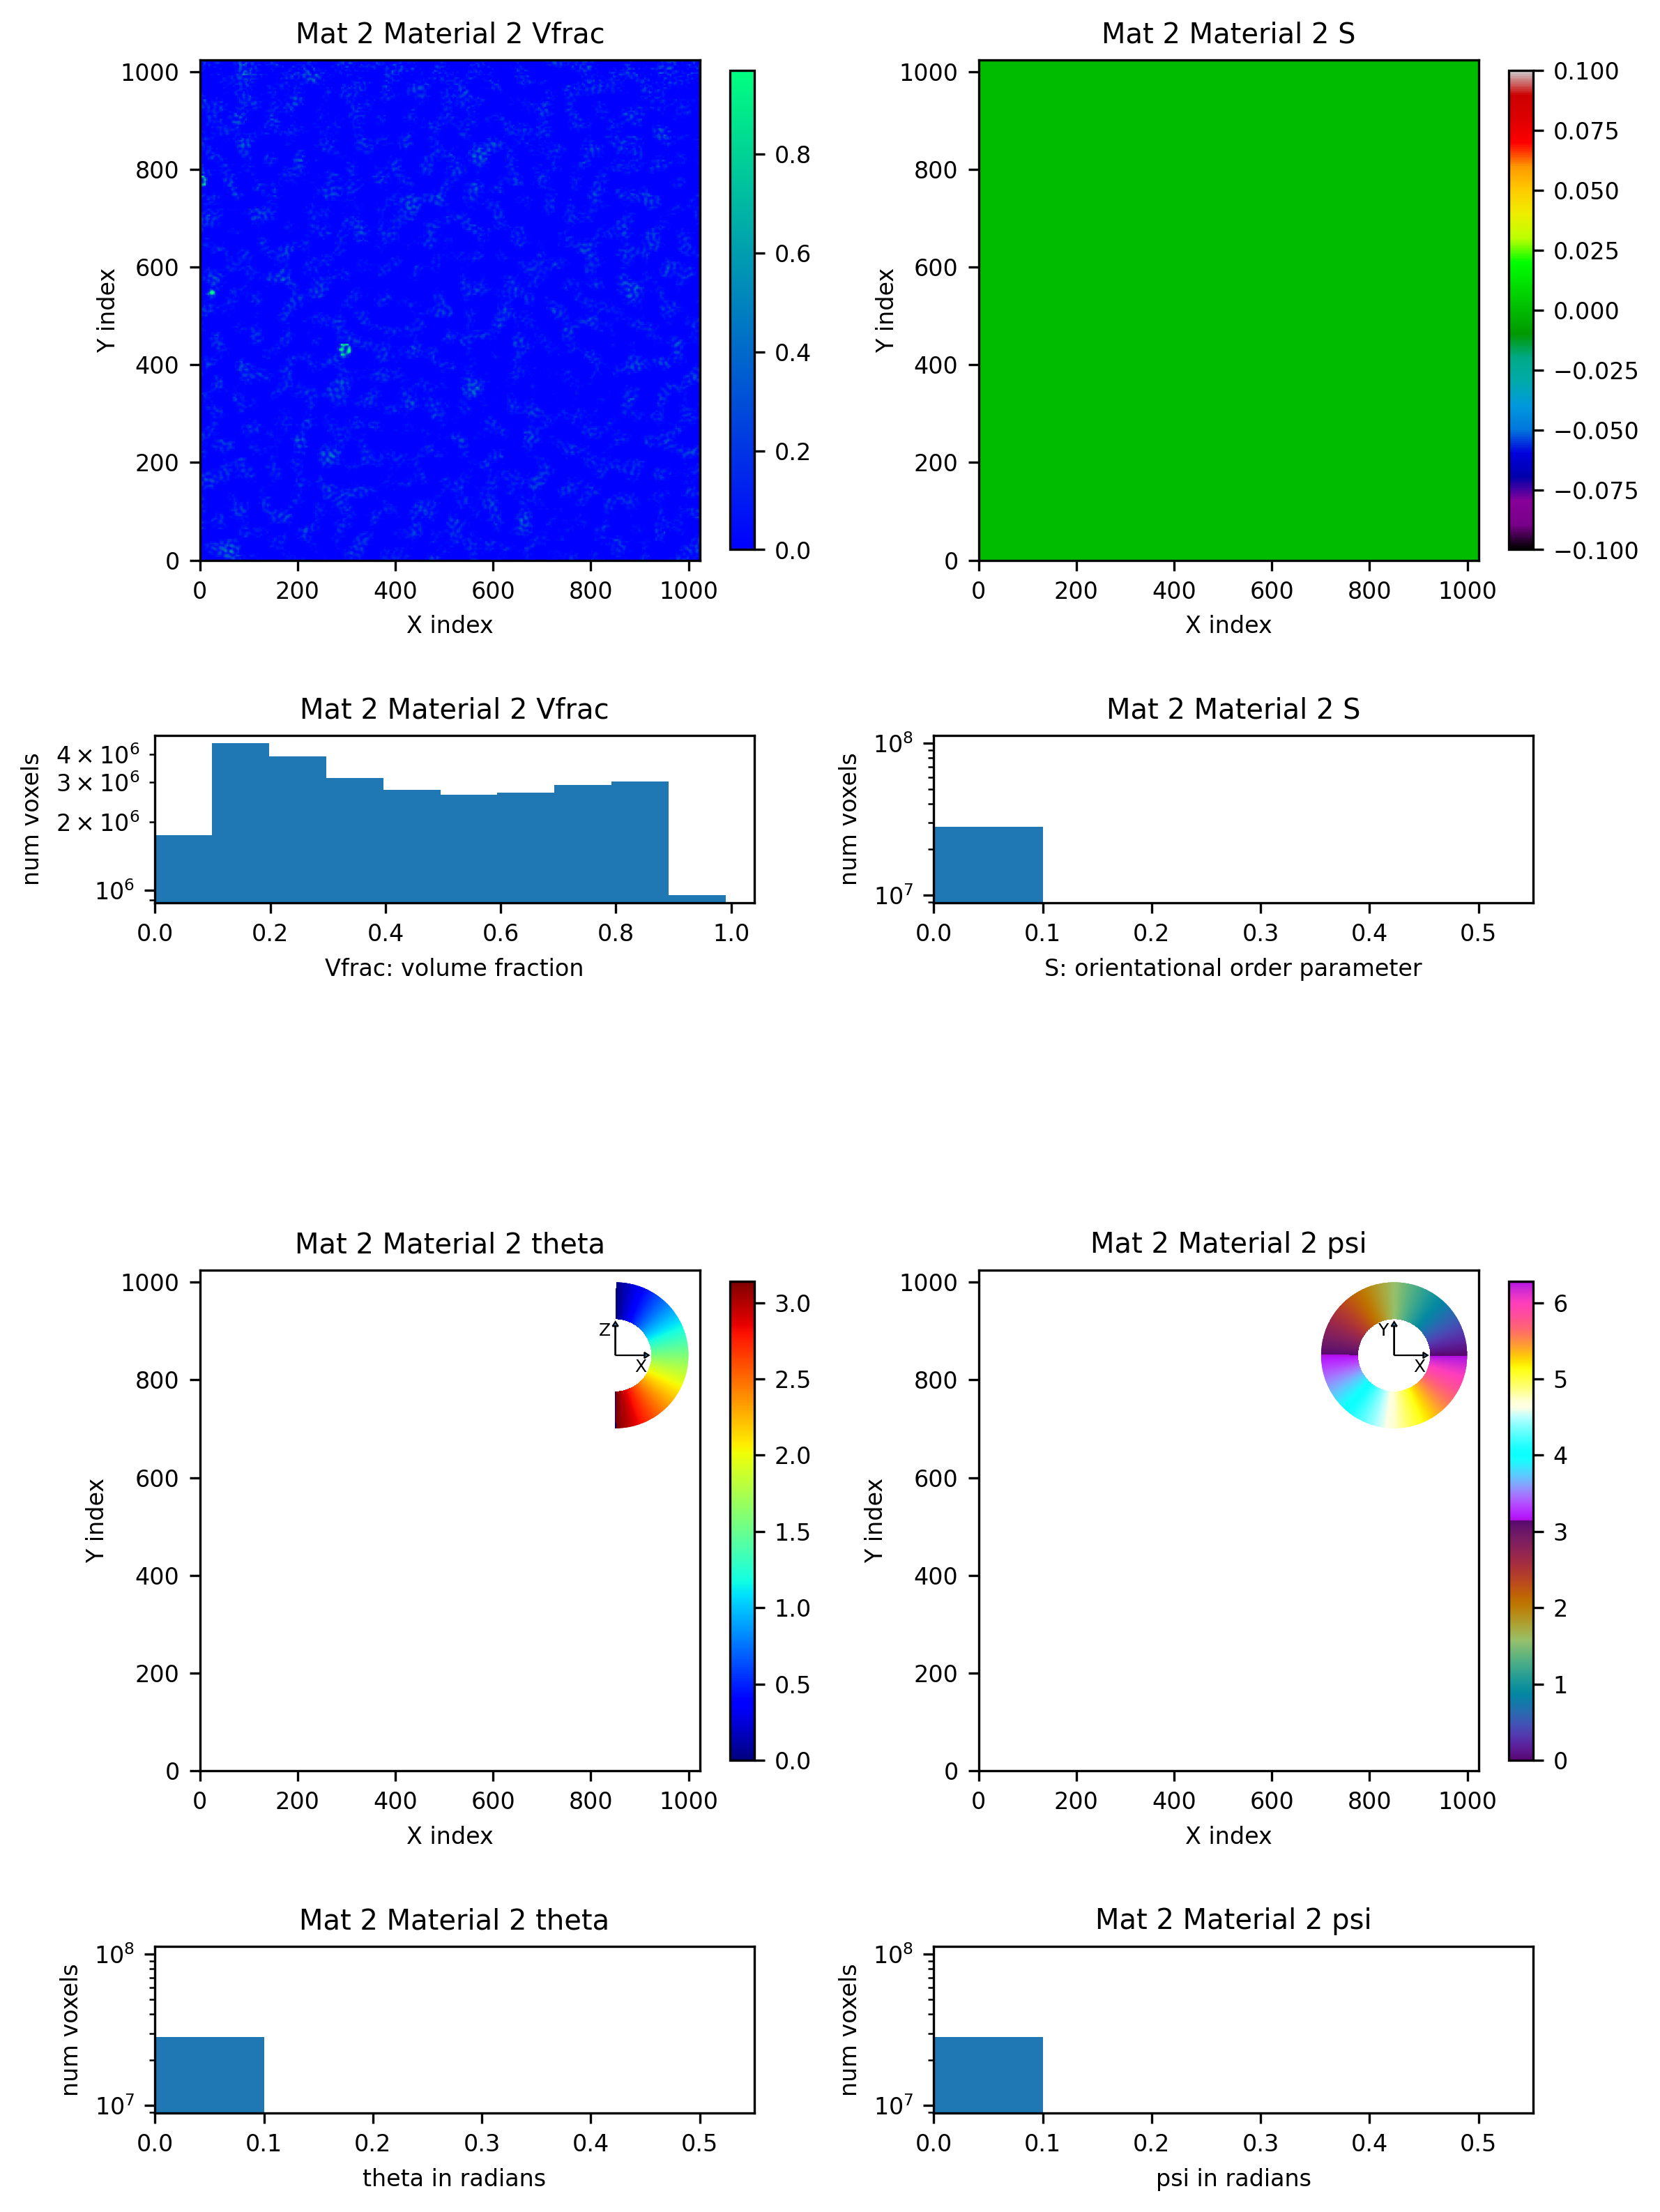

Material 3 Vfrac. Min: 0.0 Max: 1.0
Material 3 S. Min: 0.0 Max: 0.0
Material 3 theta. Min: 0.0 Max: 0.0
Material 3 psi. Min: 0.0 Max: 0.0


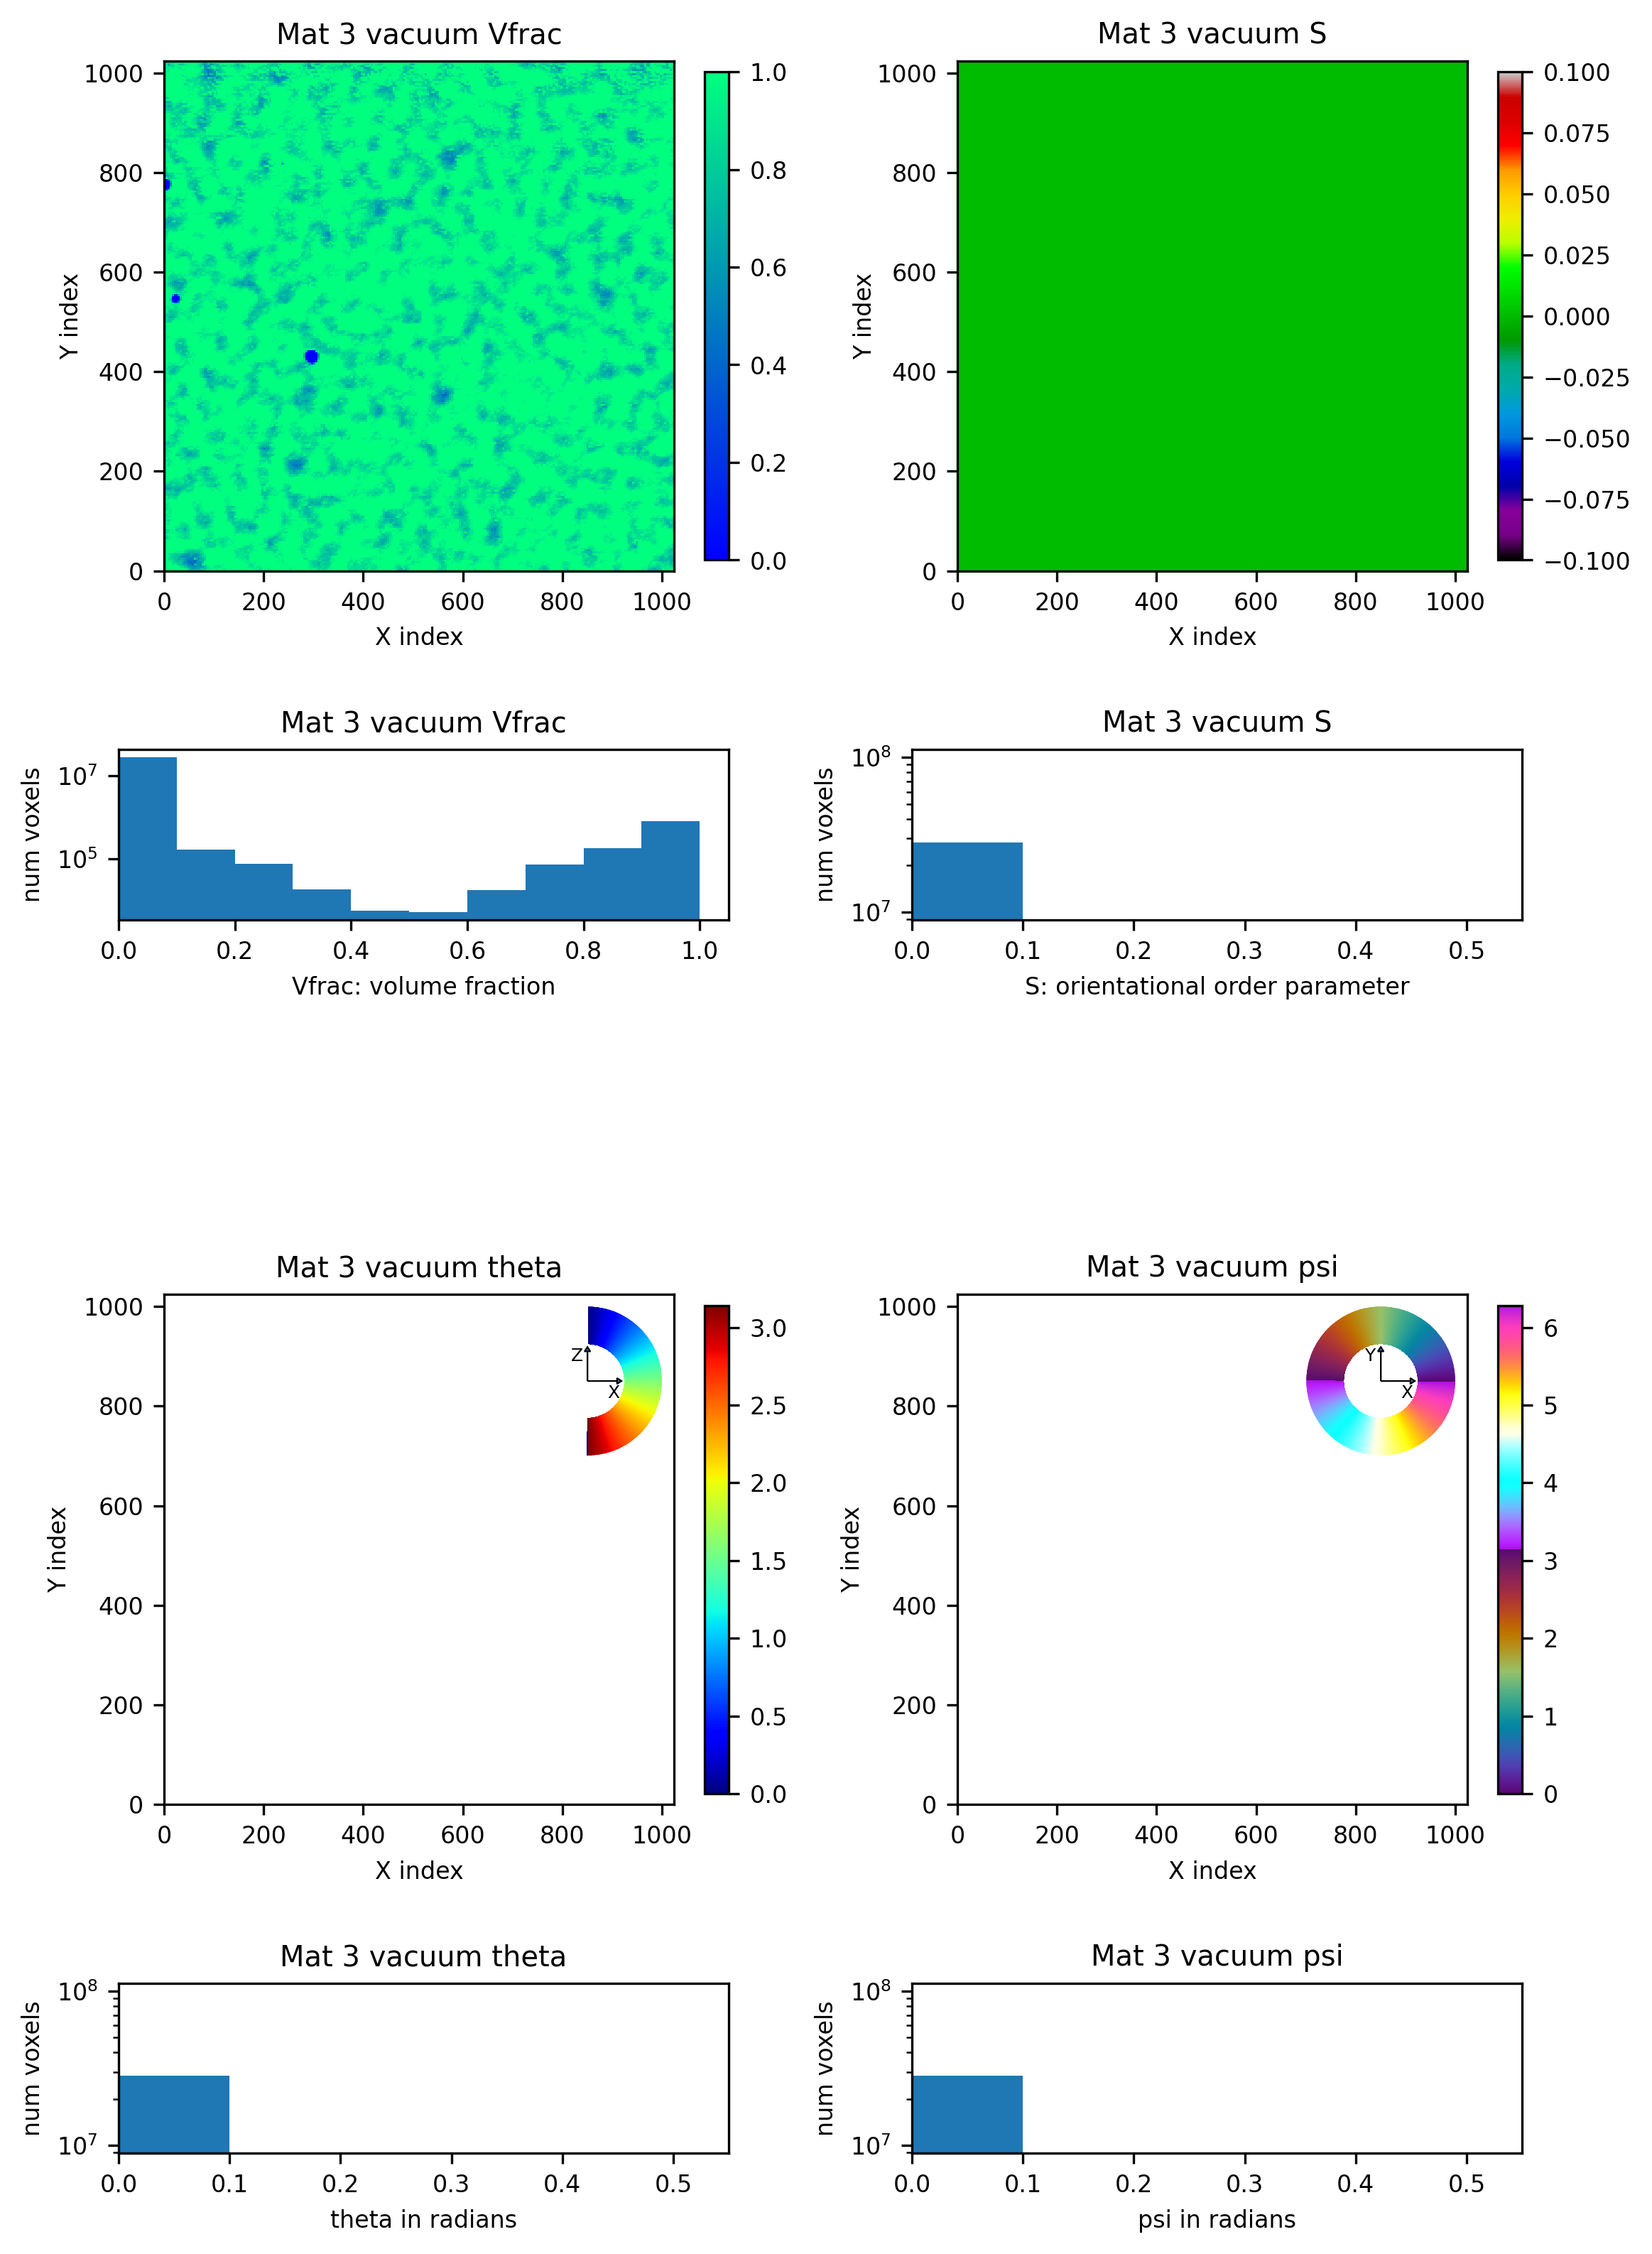

[]

<Figure size 640x480 with 0 Axes>

In [77]:
viz.morphology_visualizer(morph, z_slice=26)

In [78]:
scattering = morph.run()
remeshed    = integrator.integrateImageStack(scattering)


 [STAT] Executing: 

Number of CUDA devices:1
[INFO] [GPU = NVIDIA RTX A6000] : 270eV -> 350eV
 [STAT] Energy = 270 starting 
 [STAT] Energy = 287.4 starting 
 [STAT] Energy = 350 starting 


  0%|          | 0/3 [00:00<?, ?it/s]

/home/cbishop/anaconda3/envs/spm_soft/lib/python3.11/site-packages/xarray/core/concat.py:500: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


### Plot results

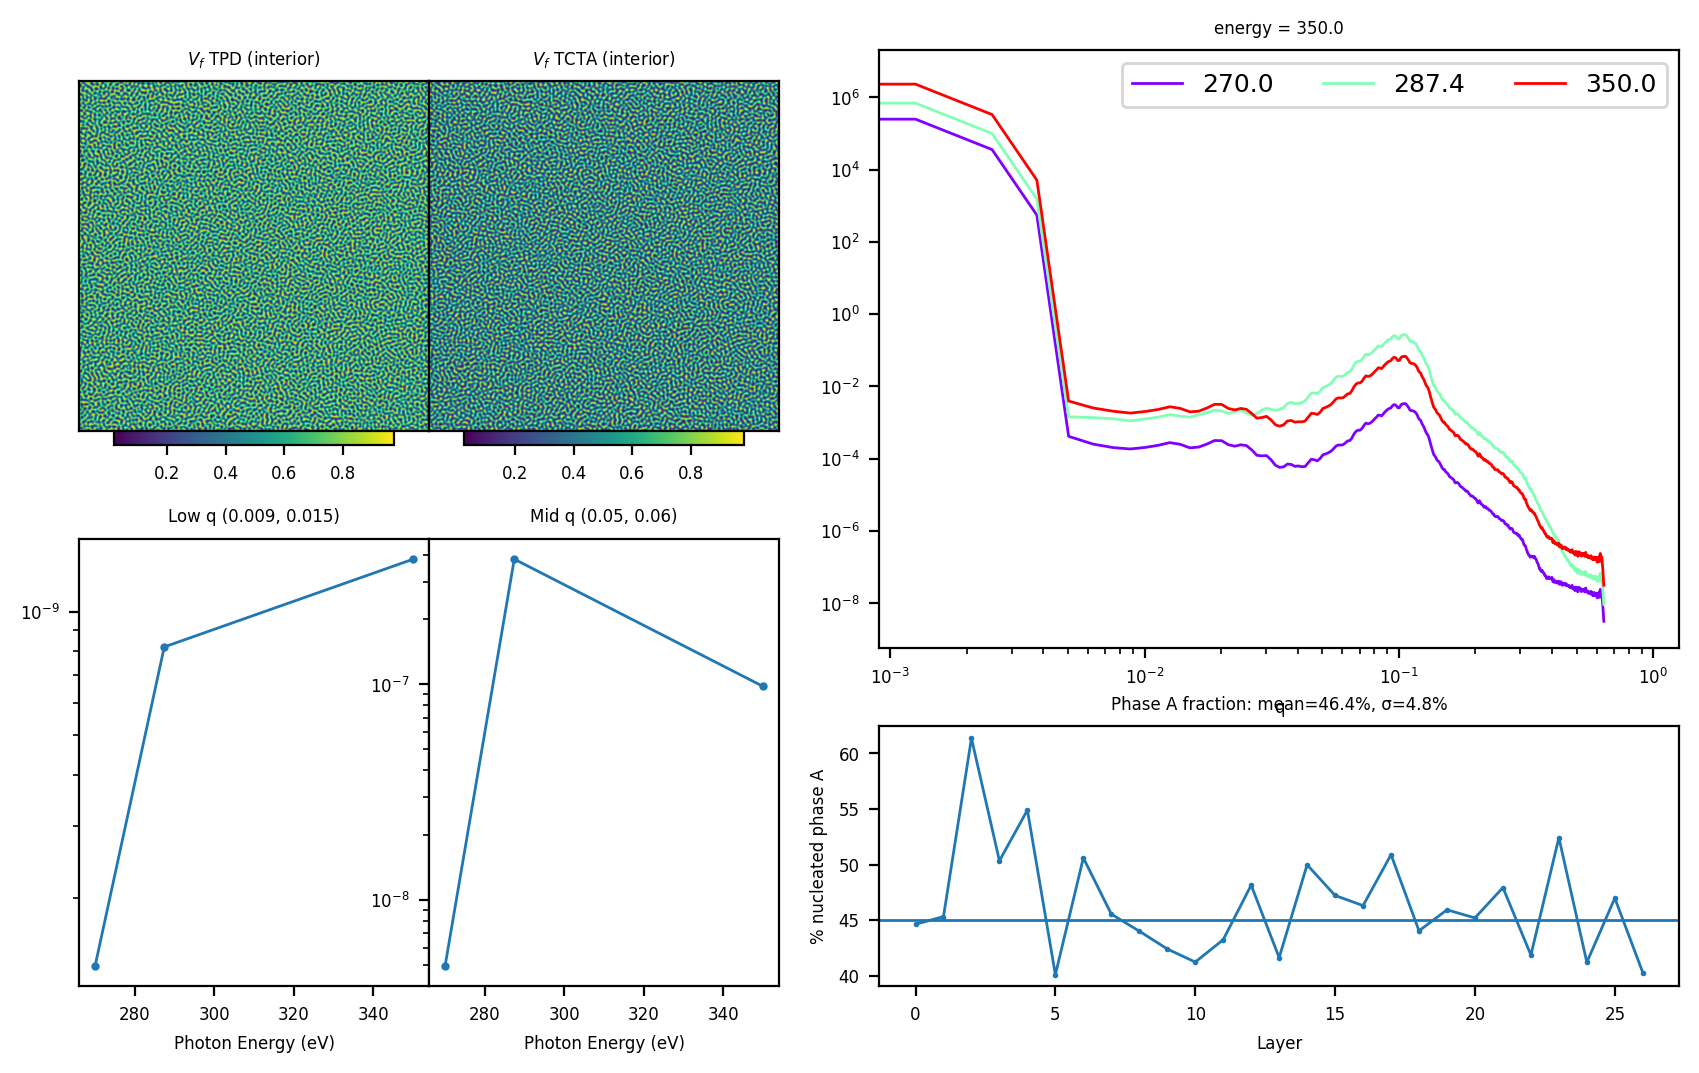

In [81]:
plt.close()

dpi = 200
fontsize = 6
plt.rcParams.update({
    "axes.labelsize":   fontsize,
    "axes.titlesize":   fontsize,
    "legend.fontsize":  fontsize,
    "xtick.labelsize":  fontsize,
    "ytick.labelsize":  fontsize,
    "lines.linewidth":  1,
    "lines.markersize": 1.,
})

fig = plt.figure(figsize=(10., 6.), dpi=dpi)

gs_morph = plt.GridSpec(4, 4, left=0.1, right=0.45, wspace=0, bottom=0.1)
ax1    = fig.add_subplot(gs_morph[0:2, 0:2])
ax2    = fig.add_subplot(gs_morph[0:2, 2:4])
axISI1 = fig.add_subplot(gs_morph[2:4, 0:2])
axISI2 = fig.add_subplot(gs_morph[2:4, 2:4])

gs_scat = plt.GridSpec(3, 2, left=0.5, right=0.9, bottom=0.1, hspace=0.3)
ax_sc  = fig.add_subplot(gs_scat[0:2, :])
ax_sum = fig.add_subplot(gs_scat[2:, :])

cb = ax1.imshow(morph.materials[1].Vfrac[23]); ax1.set_title(r'$V_{f}$ TPD (interior)')
plt.colorbar(cb, ax=ax1, shrink=0.8, location='bottom', pad=0)
cb = ax2.imshow(morph.materials[2].Vfrac[23]); ax2.set_title(r'$V_{f}$ TCTA (interior)')
plt.colorbar(cb, ax=ax2, shrink=0.8, location='bottom', pad=0)

for a in [ax1, ax2]:
    a.set_xticks([]); a.set_yticks([])

ISIs1 = []
ISIs2 = []
pcol = iter(cm.rainbow(np.linspace(0, 1, len(energies))))
for e in energies:
    color = next(pcol)
    remeshed.sel(energy=e).mean('chi').plot(label=str(e), color=color, ax=ax_sc)
    Iqarr = remeshed.sel(energy=e, method='nearest').mean('chi')
    q = np.asarray(Iqarr['q'])
    I = np.asarray(Iqarr)
    np.savetxt(os.path.join(RESULTS_DIR, f'model_CH_Wpt3_{round(e, 2)}eV.txt'),
               np.column_stack((q, I)))
    da = xr.DataArray(data=I, coords=[q], dims=['q']).sortby('q')
    q2  = np.asarray(da['q'] ** 2)
    Iq2 = da * q2
    ISIs1.append(float(Iq2.where(Iq2['q'] > qch1[0]).where(Iq2['q'] < qch1[1])
                       .dropna(dim='q').integrate(coord='q')))
    ISIs2.append(float(Iq2.where(Iq2['q'] > qch2[0]).where(Iq2['q'] < qch2[1])
                       .dropna(dim='q').integrate(coord='q')))

ax_sc.loglog()
ax_sc.legend(bbox_to_anchor=(1, 1), ncol=3, fontsize=9)

axISI1.plot(energies, ISIs1, '-o', markersize=2)
axISI2.plot(energies, ISIs2, '-o', markersize=2)
axISI1.semilogy(); axISI2.semilogy()
axISI1.set_xlabel('Photon Energy (eV)'); axISI2.set_xlabel('Photon Energy (eV)')
axISI1.set_title(f'Low q {qch1}')
axISI2.set_title(f'Mid q {qch2}')

ax_sum.plot(Apcts, '-o')
ax_sum.set_xlabel('Layer')
ax_sum.set_ylabel('% nucleated phase A')
ax_sum.axhline(45)
ax_sum.set_title(f'Phase A fraction: mean={round(np.mean(Apcts), 1)}%, '
                 f'σ={round(np.std(Apcts), 1)}%')

plt.savefig(os.path.join(RESULTS_DIR, 'CHscattering.png'), bbox_inches='tight', dpi=dpi)